In [1]:
# Run this setup only in Google Colab
import os
import subprocess
import sys
    
try:
    from google.colab import drive
    drive.mount("/content/drive")
    os.chdir("/content/drive/MyDrive/Colab Notebooks/ml2_trabalhos_2026")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"])
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-e", ".", "--no-deps"])
except ModuleNotFoundError:
    print("Not running in Colab; skipping Drive mount and install steps.")

Not running in Colab; skipping Drive mount and install steps.


# Trabalho 1 — Classificação de imagens com o Oxford-IIIT Pet

Neste trabalho, você irá treinar e comparar diferentes modelos para classificação de raças no dataset **Oxford-IIIT Pet**.

**Objetivos.**
- construir um pipeline básico de classificação de imagens;
- comparar arquiteturas simples e profundas;
- investigar o efeito de escolhas de treinamento;
- analisar erros e limitações do modelo.

**Entregáveis.**
1. Este notebook preenchido e executado.
2. Os pesos do melhor modelo;
2. Respostas curtas e objetivas nas células de texto.
3. Tabelas e gráficos pedidos ao longo do trabalho.

**Regras gerais.**
- Use **PyTorch**.
- Registre as escolhas principais de hiperparâmetros.
- Quando o enunciado pedir comparação, use evidências dos seus resultados.
- Não apague as células do enunciado.
- Use o conjunto de **teste** apenas na etapa final.



## Parte 0 — Setup e reprodutibilidade

Como treinamos algoritmos que possuem escolhas randômicas, e em máquinas com configurações possivelmente distintas. É importante tentar controlar essas variáveis para garantirmos o máximo de reprodutibilidade dos nossos experimentos.

**Tarefa 0.1**  
Fixe as seeds aleatórias e configure o dispositivo (`cpu` ou `cuda`).

**Tarefa 0.2**  
Imprima as versões de `torch` e `torchvision`, e indique se o notebook está usando CPU ou GPU.

**Tarefa 0.3**  
Crie uma variável `student_run_tag` com uma string curta de sua escolha (por exemplo, suas iniciais e a data).  
Use essa tag ao salvar modelos, figuras e demais artefatos produzidos no notebook.



In [2]:
# TODO: importe as bibliotecas principais
import random
import numpy as np
from pathlib import Path

import torch
import torchvision

# Sugestão: complete com torch.nn, torch.optim, matplotlib etc.
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
from tqdm import tqdm

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
# Adição de generator com a seed setada:
generator = torch.Generator().manual_seed(seed)

# torch.backend.cudnn.deterministic = True
# torch.backend.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Semente: {seed}")
print(f"Dispositivo: {device}")
print("Versão do Torch:", torch.__version__)
print("Versão do Torchvision:", torchvision.__version__)

student_run_tag = "tainaqd"
output_dir = Path("assignment1_outputs")
output_dir.mkdir(exist_ok=True)
(output_dir / student_run_tag).mkdir(exist_ok=True)
print("Diretório de saída:", output_dir / student_run_tag)

Semente: 42
Dispositivo: cuda
Versão do Torch: 2.11.0+cu126
Versão do Torchvision: 0.26.0+cu126
Diretório de saída: assignment1_outputs/tainaqd


## 1. Carregar dados e fazer split

Use o dataset **Oxford-IIIT Pet** do `torchvision`.

**Tarefas**
1. Baixe/carregue o dataset.
2. Separe os dados em **treino**, **validação** e **teste**.
3. Explique brevemente qual split você usou.
4. Mostre o número de exemplos em cada parte.

**Observação.**
- Você pode usar o split oficial de treino/teste e separar parte do treino para validação.
- Para a maior parte do trabalho, use inicialmente transformações simples.


In [3]:
# TODO:
# - importar OxfordIIITPet
# - definir transformações iniciais
# - carregar conjuntos
# - criar split treino/validação
# - criar DataLoaders

# Estrutura sugerida:
from torchvision.datasets import OxfordIIITPet
from torchvision import transforms
from torch.utils.data import DataLoader, random_split

image_size = 224
batch_size = 64

# Escreva seu código aqui
transform = transforms.ToTensor()

In [4]:
# Download do dataset separado para treino/validação e teste
trainval_dataset = OxfordIIITPet(root="./data", split="trainval", transform=transform, download=True)
test_dataset = OxfordIIITPet(root="./data", split="test", transform=transform, download=True)

In [5]:
# Separação de treino e validação
val_size = int(0.2 * len(trainval_dataset))
train_size = len(trainval_dataset) - val_size

train_dataset, val_dataset = random_split(trainval_dataset, [train_size, val_size], generator=generator)

In [6]:
# Criação dos DataLoaders
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

### Resposta 1.3

Explique brevemente como você construiu o split de treino, validação e teste.


Inicialmente, utilizei o split padrão do dataset para separar em treino e teste. 
Depois, dividi o dataset de treino em 80% para treino e 20% para validação usando a função random_split. Para reprodutibilide dos resultados, utilizei o generator com a seed configurada no começo deste notebook.

Por fim, com cada um dos datasets devidamente separados, construí os DataLoaders com o batch_size=64.

## 2. Visualizar dados e inspecionar balanceamento

Antes de treinar, inspecione o dataset.

**Tarefas**
1. Mostre algumas imagens com seus rótulos.
2. Conte quantos exemplos há por classe no conjunto de treino.
3. Faça um gráfico simples da distribuição por classe.
4. Comente se o conjunto parece balanceado ou não.
5. Aponte ao menos uma dificuldade visual do problema.

In [7]:
# TODO:
# - mostrar algumas imagens do treino
# - obter nomes/classes
# - contar frequência por classe
# - fazer um gráfico simples

# Escreva seu código aqui
# Análise do formato dos dados
breed_names = train_dataset.dataset.classes
print(f"Número de classes: {len(breed_names)}")

print("\Dez primeiros dados de treino:")
print(f"img format | breed id | breed name")
for i in range(10):
    image, label = train_dataset[i]
    print(image.shape, label, breed_names[label])


Número de classes: 37
\Dez primeiros dados de treino:
img format | breed id | breed name
torch.Size([3, 375, 500]) 19 Leonberger
torch.Size([3, 352, 400]) 0 Abyssinian
torch.Size([3, 500, 375]) 14 German Shorthaired
torch.Size([3, 375, 500]) 27 Russian Blue
torch.Size([3, 375, 500]) 4 Beagle
torch.Size([3, 334, 500]) 19 Leonberger
torch.Size([3, 500, 388]) 19 Leonberger
torch.Size([3, 352, 500]) 19 Leonberger
torch.Size([3, 500, 375]) 17 Japanese Chin
torch.Size([3, 333, 500]) 26 Ragdoll


<>:12: SyntaxWarning: invalid escape sequence '\D'
<>:12: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_44870/4039111709.py:12: SyntaxWarning: invalid escape sequence '\D'
  print("\Dez primeiros dados de treino:")


Imagens dos dez primeiros dados de treino:


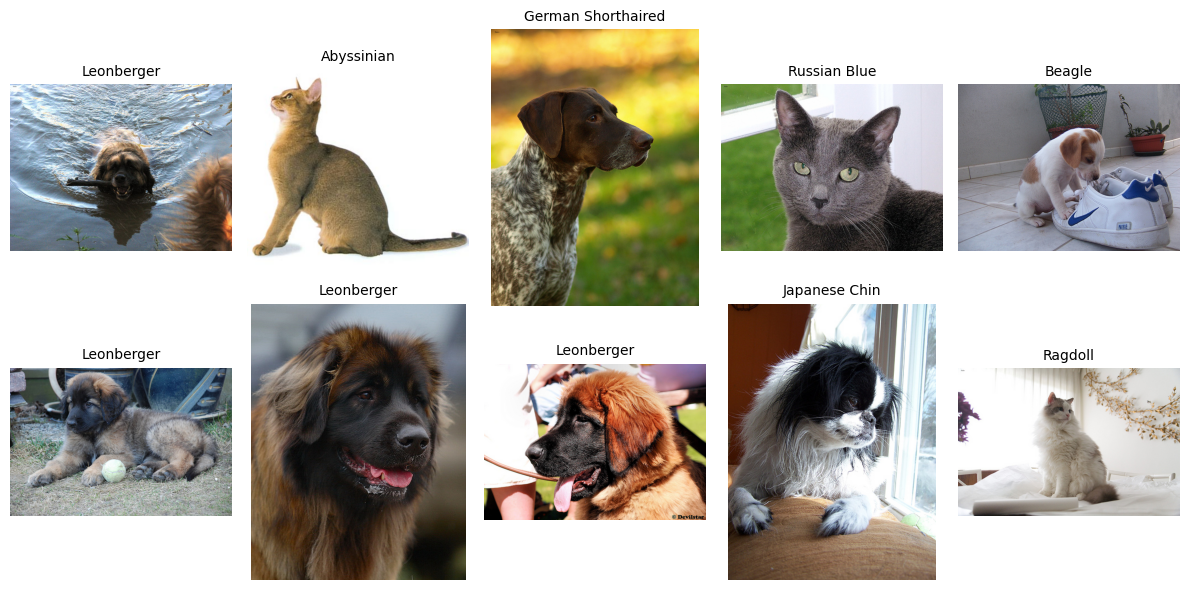

In [8]:
# Visualização de imagens
print("Imagens dos dez primeiros dados de treino:")

fig = plt.figure(figsize=(12, 6))
for i in range(10):
    ax = fig.add_subplot(2, 5, i+1)
    image, label = train_dataset[i]
    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(breed_names[label], fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [9]:
# Distribuição das classes em treino
labels = np.array([train_dataset[i][1] for i in range(len(train_dataset))])
unique, counts = np.unique(labels, return_counts=True)

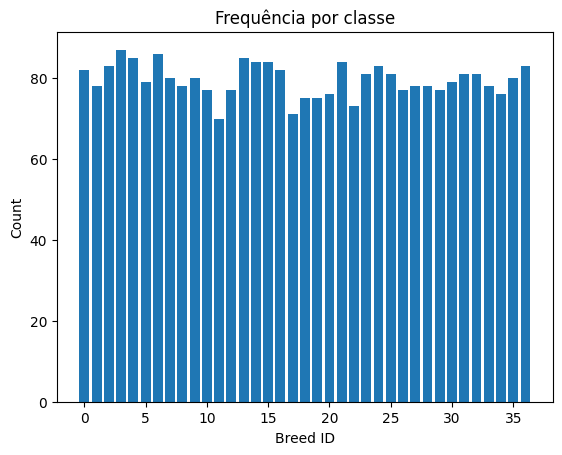

In [10]:
plt.bar(unique, counts)
plt.xlabel("Breed ID")
plt.ylabel("Count")
plt.title("Frequência por classe")
plt.show()

Como as imagens têm dimensões diferentes, precisamos redimensioná-las para um padrão comum.

In [11]:
transform_resize = transforms.Compose([
                    transforms.Resize((224, 224)),
                    transforms.ToTensor()
                ])

trainval_dataset = OxfordIIITPet(root="./data", split="trainval", transform=transform_resize, download=True)
test_dataset = OxfordIIITPet(root="./data", split="test", transform=transform_resize, download=True)

val_size = int(0.2 * len(trainval_dataset))
train_size = len(trainval_dataset) - val_size

train_dataset, val_dataset = random_split(trainval_dataset, [train_size, val_size], generator=generator)

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

### Resposta 2.4–2.5

Com base nas visualizações e na distribuição por classe, descreva brevemente o que você observou.


Identifiquei que há 37 classes distintas nesse dataset. Explorando a pasta annotations dos dados, identifiquei que essas classes correspondem a raças de gato e cachorro.

Os labels são numéricos e as imagens do dataset têm dimensões espaciais diferentes (tanto em altura quanto em largura). Todas elas possuem 3 features (RGB).

Como as redes esperam dados de dimensões fixas, eu redimensionei as imagens para todas ficarem no padrão 224x224 e redefini os DataLoaders com essa alteração.

Quanto à distribuição dos dados por classe, o dataset parece estar bem balanceado. No histograma de frequência por classe no dataset de treino, é possível notar que cada classe possui cerca de 80 observações.

## 3. Construa uma FNN simples

Agora construa um primeiro modelo totalmente conectado (**FNN**).

**Tarefas**
1. Defina uma arquitetura simples em PyTorch.
2. Sua FNN deve receber a imagem achatada.
3. Escolha dimensões ocultas razoáveis.
4. Informe o número de parâmetros do modelo.

**Observação.**
Este modelo serve como baseline simples. Não é esperado que funcione bem.


In [12]:
# TODO:
# - definir uma classe FNN(nn.Module)
# - achatar a entrada
# - retornar logits para o número de classes
# - criar uma instância do modelo

# Dica:
# class SimpleFNN(nn.Module):
#     ...

# Escreva seu código aqui
class SimpleFNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        layer_sizes = [3*224*224, 512, 256, 128, 37]
        layers = []
        
        for i in range(len(layer_sizes) - 1):
            layers.append(
                nn.Linear(layer_sizes[i], layer_sizes[i+1])
            )
            if i != len(layer_sizes) - 2:
                layers.append(nn.ReLU())
                
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        out = x.reshape(x.size(0), -1)
        out = self.network(out)
            
        return out

TODO: NÚMERO DE PARÂMETROS DO MODELO

## 4. Crie funções de treino e avaliação

Implemente funções reutilizáveis para os próximos experimentos.

**Tarefas**
1. Crie uma função `train_one_epoch`.
2. Crie uma função `evaluate`.
3. Crie uma função `fit` que registre métricas por época.
4. Sua avaliação deve retornar pelo menos:
   - loss média
   - acurácia

**Importante.**
Essas funções serão reutilizadas em várias partes do trabalho.


### Resposta 4.1

In [13]:
# TODO:
# - implementar train_one_epoch
# - implementar evaluate
# - implementar fit
# - opcional: salvar histórico em dicionário

# Assinaturas sugeridas:
# def train_one_epoch(model, loader, optimizer, criterion, device):
#     ...
#
# @torch.no_grad()
# def evaluate(model, loader, criterion, device):
#     ...
#
# def fit(model, train_loader, val_loader, optimizer, criterion, device, epochs, scheduler=None):
#     ...

# Escreva seu código aqui

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

### Resposta 4.2

In [14]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    correct = 0
    total = 0
    running_loss = 0.0
    
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        
        loss = criterion(outputs, labels)
        running_loss += loss.item()

        total += labels.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        
    loss = running_loss / len(loader)
    accuracy = 100 * correct / total

    return loss, accuracy

### Resposta 4.3

In [15]:
def fit(model, train_loader, val_loader, optimizer, criterion, device, epochs, scheduler=None, verbose=True):
    train_loss_hist = []
    val_loss_hist = []
    train_accuracy_hist = []
    val_accuracy_hist = []
    
    pbar = tqdm(range(epochs))
    for i in pbar:
        train_one_epoch(model, train_loader, optimizer, criterion, device)
        
        train_loss, train_accuracy = evaluate(model, train_loader, criterion, device)
        train_loss_hist.append(train_loss)
        train_accuracy_hist.append(train_accuracy)

        val_loss, val_accuracy = evaluate(model, val_loader, criterion, device)
        val_loss_hist.append(val_loss)
        val_accuracy_hist.append(val_accuracy)
        
        print(
            f"Loss em treino: {train_loss}\n"
            f"Acurácia em treino: {train_accuracy}, "
            f"Acurácia em validação: {val_accuracy}"
        )
    
    return train_loss_hist, train_accuracy_hist, val_loss_hist, val_accuracy_hist

## 5. Treine e avalie a FNN

Use as funções anteriores para treinar sua FNN.

**Tarefas**
1. Escolha uma loss apropriada.
2. Escolha um otimizador.
3. Treine por algumas épocas.
4. Mostre curvas de treino/validação.
5. Reporte as métricas finais em validação.
6. Faça um comentário curto sobre o desempenho da FNN.

**Sugestão.**
Registre as escolhas de hiperparâmetros em uma célula ou tabela.


In [54]:
# TODO:
# - definir criterion e optimizer
# - treinar a FNN
# - guardar histórico
# - plotar curvas
# - reportar métricas finais

# Escreva seu código aqui

model = SimpleFNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [ ]:
epochs = 50
train_loss_hist, train_accuracy_hist, val_loss_hist, val_accuracy_hist = \
fit(model, train_loader, val_loader, optimizer, criterion, device, epochs)

  2%|▎         | 1/40 [00:13<08:58, 13.80s/it]

Loss em treino: 3.606833172881085
Acurácia em treino: 2.5815217391304346, Acurácia em validação: 3.8043478260869565


  5%|▌         | 2/40 [00:27<08:51, 14.00s/it]

Loss em treino: 3.611838003863459
Acurácia em treino: 2.8872282608695654, Acurácia em validação: 2.4456521739130435


  8%|▊         | 3/40 [00:41<08:36, 13.97s/it]

...

Loss em treino: 2.948568053867506
Acurácia em treino: 16.440217391304348, Acurácia em validação: 8.423913043478262


 98%|█████████▊| 39/40 [08:47<00:13, 13.85s/it]

Loss em treino: 2.8259525661883145
Acurácia em treino: 18.308423913043477, Acurácia em validação: 8.559782608695652


100%|██████████| 40/40 [09:00<00:00, 13.51s/it]

Loss em treino: 2.716687622277633
Acurácia em treino: 21.467391304347824, Acurácia em validação: 10.326086956521738


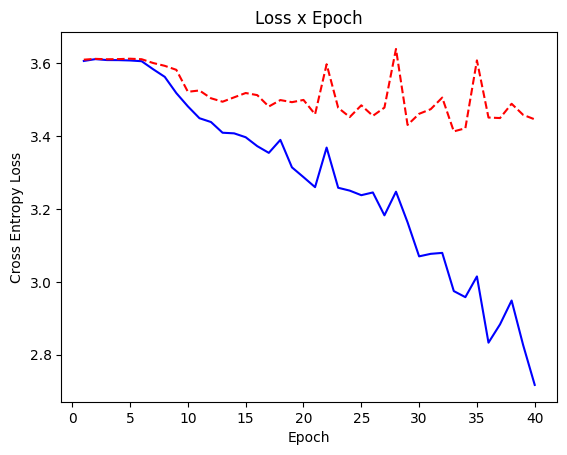

In [56]:
epoch_range = range(1, epochs+1)

plt.title("Loss x Epoch")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.plot(epoch_range, train_loss_hist, label="Train loss", color="blue", linestyle="-")
plt.plot(epoch_range, val_loss_hist, label="Validation loss", color="red", linestyle="--")
plt.show()

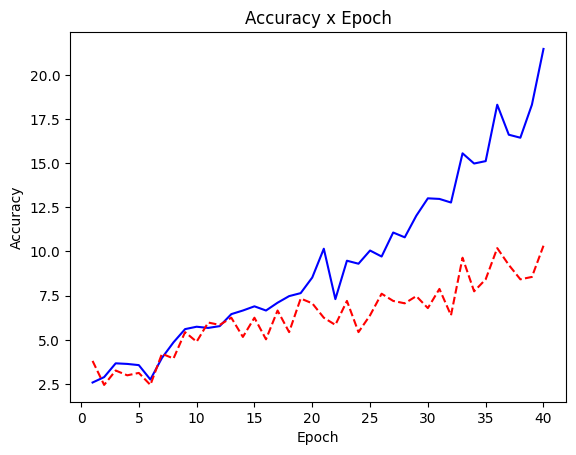

In [57]:
plt.title("Accuracy x Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.plot(epoch_range, train_accuracy_hist, label="Train accuracy", color="blue", linestyle="-")
plt.plot(epoch_range, val_accuracy_hist, label="Validation accuracy", color="red", linestyle="--")
plt.show()

In [58]:
# Desempenho em teste
_, test_accuracy = evaluate(model, test_loader, criterion, device)
print(test_accuracy)

7.958571817934042


### Resposta 5.6

Comente brevemente o desempenho da FNN. Ela parece adequada para esse problema? Por quê?


## 6. Construa uma CNN simples e compare com a FNN

Agora implemente uma CNN simples.

**Tarefas**
1. Defina uma CNN com algumas camadas convolucionais.
2. Treine e avalie a CNN usando o mesmo protocolo da FNN.
3. Compare FNN e CNN em termos de:
   - acurácia;
   - comportamento das curvas;
   - número de parâmetros.

**Observação.**
A comparação deve ser baseada nos seus resultados.


### Resposta 6.1

In [59]:
# TODO:
# - definir uma CNN simples
# - treinar
# - avaliar
# - comparar com a FNN

# Dica:
# class SimpleCNN(nn.Module):
#     ...

# Escreva seu código aqui

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            
            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            
            nn.Flatten(),
            
            nn.Linear(3200, 1024),
            nn.ReLU(),
            nn.Linear(1024, 37),
        )
    
    def forward(self, x):
        out = self.network(x)
        
        return out


### Resposta 6.2

In [60]:
simple_cnn_model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(simple_cnn_model.parameters())

In [61]:
epochs = 30

train_loss_hist, train_accuracy_hist, val_loss_hist, val_accuracy_hist = \
fit(simple_cnn_model, train_loader, val_loader, optimizer, criterion, device, epochs)

  3%|▎         | 1/30 [00:13<06:22, 13.19s/it]

Loss em treino: 3.6104090939397397
Acurácia em treino: 2.8532608695652173, Acurácia em validação: 2.1739130434782608


  7%|▋         | 2/30 [00:26<06:10, 13.23s/it]

Loss em treino: 3.610150088434634
Acurácia em treino: 2.8872282608695654, Acurácia em validação: 2.0380434782608696


 10%|█         | 3/30 [00:40<06:03, 13.48s/it]

...

Loss em treino: 3.6094615770422895
Acurácia em treino: 3.0230978260869565, Acurácia em validação: 1.4945652173913044


 90%|█████████ | 27/30 [06:04<00:40, 13.35s/it]

Loss em treino: 3.6094764782034834
Acurácia em treino: 3.0230978260869565, Acurácia em validação: 1.4945652173913044


 90%|█████████ | 27/30 [06:18<00:42, 14.00s/it]


KeyboardInterrupt: 

### Resposta 6.3

Compare FNN e CNN de forma objetiva. O que mudou? O resultado era esperado?


## 7. Faça pelo menos 3 modificações no treinamento

A partir da sua CNN simples, escolha **pelo menos 3** modificações da lista abaixo:

- Dara Augmentation;
- outro otimizador;
- learning rate scheduler;
- batch normalization;
- dropout;
- CNN mais profunda;
- weight decay regularizer.

**Tarefas**
1. Escolha no mínimo 3 modificações.
2. Execute experimentos controlados.
3. Organize os resultados em uma tabela.
4. Indique claramente qual configuração foi a melhor.

**Importante.**
Tente mudar uma coisa por vez sempre que possível.


### Resposta 7.1

In [ ]:
# TODO:
# - definir ao menos 3 experimentos
# - treinar cada configuração
# - registrar resultados em uma tabela final

# Data Augmentation
# dropout
# batch normalization


In [16]:
class NormalizedCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.BatchNorm2d(3),

            nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3),
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            
            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            
            nn.Flatten(),
            
            nn.Linear(3200, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),

            nn.Linear(1024, 37),
        )
    
    def forward(self, x):
        out = self.network(x)
        
        return out

In [17]:
model = NormalizedCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [18]:
epochs = 40

train_loss_hist, train_accuracy_hist, val_loss_hist, val_accuracy_hist = \
fit(model, train_loader, val_loader, optimizer, criterion, device, epochs)

  2%|▎         | 1/40 [00:13<09:05, 13.98s/it]

Loss em treino: 3.4916419620099277
Acurácia em treino: 14.164402173913043, Acurácia em validação: 10.46195652173913


  5%|▌         | 2/40 [00:26<08:25, 13.31s/it]

Loss em treino: 1.8291132605594138
Acurácia em treino: 52.17391304347826, Acurácia em validação: 21.875


  8%|▊         | 3/40 [00:39<08:02, 13.05s/it]

...

Loss em treino: 0.006470651122862878
Acurácia em treino: 100.0, Acurácia em validação: 31.11413043478261


 20%|██        | 8/40 [01:45<06:56, 13.02s/it]

Loss em treino: 0.00452850167842015
Acurácia em treino: 100.0, Acurácia em validação: 31.11413043478261


 20%|██        | 8/40 [01:57<07:48, 14.63s/it]


KeyboardInterrupt: 

In [16]:
class DropoutCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            
            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            
            nn.Flatten(),
            
            nn.Linear(3200, 1024),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(1024, 37),
        )
    
    def forward(self, x):
        out = self.network(x)
        
        return out

In [17]:
model = DropoutCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [18]:
epochs = 40

train_loss_hist, train_accuracy_hist, val_loss_hist, val_accuracy_hist = \
fit(model, train_loader, val_loader, optimizer, criterion, device, epochs)

  2%|▎         | 1/40 [00:13<08:52, 13.65s/it]

Loss em treino: 3.610612952190897
Acurácia em treino: 2.717391304347826, Acurácia em validação: 2.717391304347826


  5%|▌         | 2/40 [00:27<08:50, 13.95s/it]

Loss em treino: 3.610250281250995
Acurácia em treino: 3.0230978260869565, Acurácia em validação: 1.4945652173913044


  8%|▊         | 3/40 [00:41<08:27, 13.72s/it]

...

Loss em treino: 3.6094665682834126
Acurácia em treino: 3.0230978260869565, Acurácia em validação: 1.4945652173913044


 98%|█████████▊| 39/40 [08:39<00:13, 13.32s/it]

Loss em treino: 3.6094616599704907
Acurácia em treino: 3.0230978260869565, Acurácia em validação: 1.4945652173913044


100%|██████████| 40/40 [08:52<00:00, 13.31s/it]

Loss em treino: 3.6094448721927144
Acurácia em treino: 3.0230978260869565, Acurácia em validação: 1.4945652173913044


### Resposta 7.4

Liste as modificações escolhidas e justifique em 1–2 linhas por que você decidiu testá-las.


## 8. Analise e discuta o efeito das mudanças

Com base nos experimentos da parte anterior:

**Tarefas**
1. Discuta quais mudanças ajudaram mais.
2. Discuta quais mudanças pouco ajudaram ou pioraram o resultado.
3. Comente possíveis razões para o comportamento observado.
4. Indique qual modelo/configuração você levará para a etapa final.

Use evidências das métricas e curvas.


### Resposta 8

Escreva sua análise aqui.


## 9. Treine usando uma ResNet pré-treinada

Agora use **transfer learning** com uma **ResNet pré-treinada**.

**Tarefas**
1. Carregue uma ResNet pré-treinada do `torchvision`.
2. Adapte a última camada para o número de classes.
3. Treine ao menos uma versão usando transfer learning.
4. Compare com sua melhor CNN da Parte 7.

**Sugestão.**
Você pode começar congelando a maior parte da rede e depois testar fine-tuning.


In [ ]:
# TODO:
# - carregar uma ResNet pré-treinada
# - adaptar a camada final
# - treinar
# - avaliar e comparar

# Dica:
# from torchvision.models import resnet18, ResNet18_Weights

# Escreva seu código aqui


### Resposta 9.4

Compare a ResNet com sua melhor CNN anterior. O ganho compensou?


## 10. Avaliações finais

Escolha seu melhor modelo final e faça uma avaliação mais detalhada.

**Tarefas**
1. Avalie no conjunto de teste.
2. Reporte:
   - loss;
   - acurácia;
   - matriz de confusão.
3. Mostre algumas imagens classificadas incorretamente.
4. Identifique pares de classes que geram mais confusão.
5. Discuta brevemente os principais erros do modelo.

**Observação.**
Use esta parte para mostrar que você inspecionou o comportamento do modelo além da acurácia final.


In [ ]:
# TODO:
# - avaliar no teste
# - calcular matriz de confusão
# - mostrar erros
# - discutir pares confusos

# Sugestão:
# use sklearn.metrics.confusion_matrix ou implementação própria

# Escreva seu código aqui


### Resposta 10.5

Discuta os erros mais importantes observados na avaliação final.


## 11. Bônus — Robustez

Faça um teste simples de robustez com o seu melhor modelo.

**Exemplos de variações possíveis**
- reduzir a resolução da imagem;
- adicionar ruído leve;
- mudar brilho/contraste;
- aplicar blur leve;
- testar imagens com crop diferente.

**Tarefas**
1. Escolha uma perturbação simples.
2. Compare o desempenho antes e depois.
3. Mostre alguns exemplos.
4. Comente o que isso sugere sobre a robustez do modelo.


In [ ]:
# TODO:
# - definir uma perturbação simples
# - reavaliar o melhor modelo
# - comparar métricas
# - mostrar exemplos

# Escreva seu código aqui

## Critérios de avaliação

A correção levará em conta:
- **implementação correta** dos componentes pedidos;
- **qualidade experimental** das comparações;
- **clareza da análise** dos resultados;
- **organização** do notebook;
- **coerência** entre conclusões e evidências.
